<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-06-25 13:38:36--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  77.5MB/s    in 2.6s    

2025-06-25 13:38:41 (77.5 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


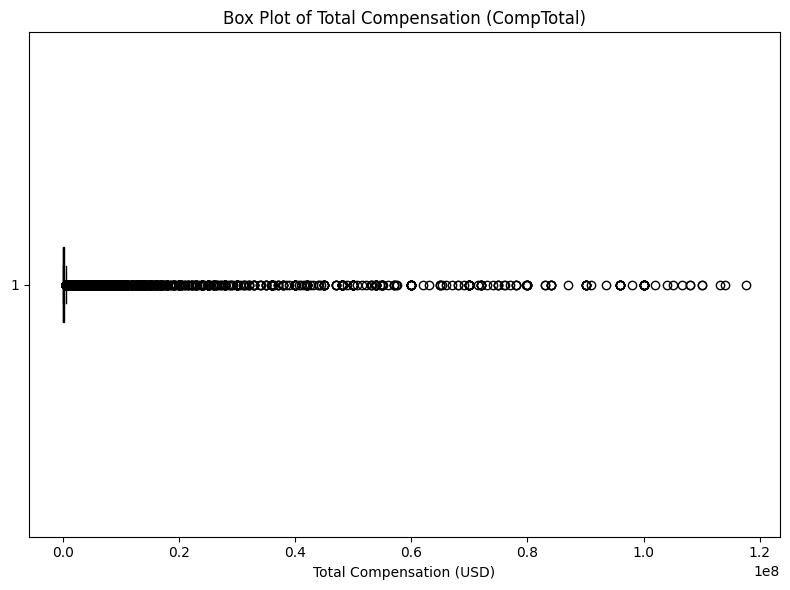

In [8]:
# your code goes here

conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing or invalid CompTotal values
comp_data = df['CompTotal'].dropna()

# Optional: filter out extreme outliers (e.g., top 1%) for a clearer box plot
comp_data = comp_data[comp_data < comp_data.quantile(0.99)]

# Plot box plot
plt.figure(figsize=(8, 6))
plt.boxplot(comp_data, vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='black'),
            medianprops=dict(color='black'))
plt.title('Box Plot of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation (USD)')
plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


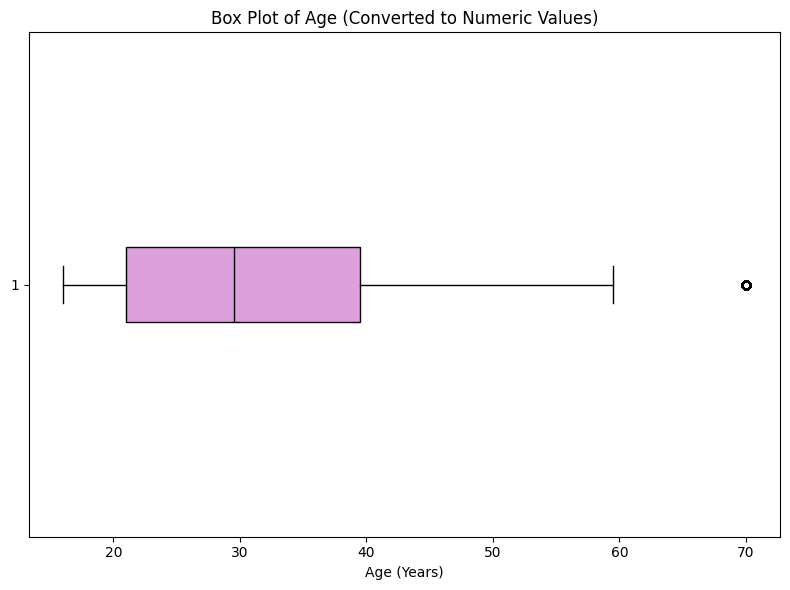

In [9]:
# your code goes here

# Connect to SQLite and load the data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Map age categories to approximate numeric values
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

# Apply the mapping
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop NaN values (e.g., "Prefer not to say")
age_numeric = df['AgeNumeric'].dropna()

# Plot box plot
plt.figure(figsize=(8, 6))
plt.boxplot(age_numeric, vert=False, patch_artist=True,
            boxprops=dict(facecolor='plum', color='black'),
            medianprops=dict(color='black'))
plt.title('Box Plot of Age (Converted to Numeric Values)')
plt.xlabel('Age (Years)')
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x600 with 0 Axes>

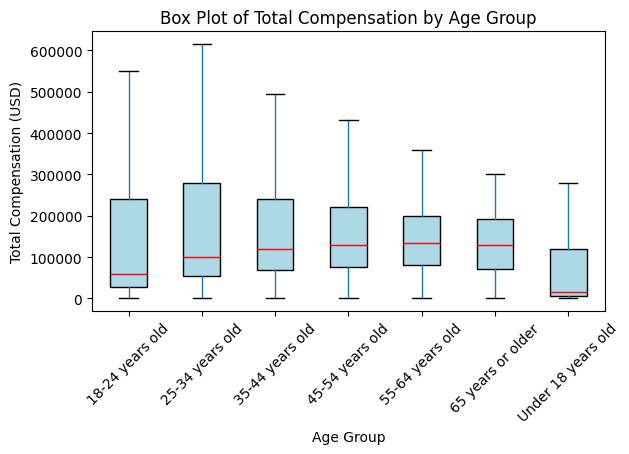

In [10]:
# your code goes here

# Connect to SQLite and load the dataset
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop rows with missing Age or CompTotal
df = df[['Age', 'CompTotal']].dropna()

# Optional: filter out extreme outliers in CompTotal for better plot readability (e.g., top 1%)
df = df[df['CompTotal'] < df['CompTotal'].quantile(0.99)]

# Define age group order for meaningful x-axis sorting
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Filter only rows with defined age categories
df = df[df['Age'].isin(age_order)]

# Plot boxplot grouped by Age
plt.figure(figsize=(12, 6))
df.boxplot(column='CompTotal', by='Age', grid=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red'))
plt.title('Box Plot of Total Compensation by Age Group')
plt.suptitle('')  # Remove automatic subtitle
plt.xlabel('Age Group')
plt.ylabel('Total Compensation (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 1200x600 with 0 Axes>

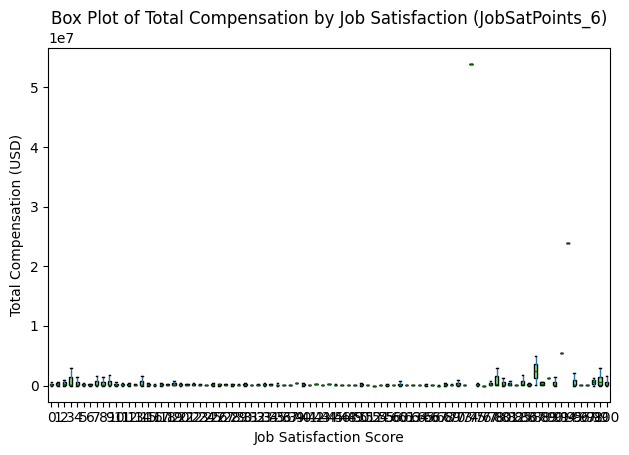

In [11]:
# your code goes here

# Connect to SQLite and load the data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop rows with missing JobSatPoints_6 or CompTotal
df = df[['JobSatPoints_6', 'CompTotal']].dropna()

# Optional: remove top 1% compensation outliers for better visualization
df = df[df['CompTotal'] < df['CompTotal'].quantile(0.99)]

# Convert JobSatPoints_6 to integer if needed
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# Sort by Job Satisfaction score
df = df.sort_values(by='JobSatPoints_6')

# Plot boxplot grouped by JobSatPoints_6
plt.figure(figsize=(12, 6))
df.boxplot(column='CompTotal', by='JobSatPoints_6', grid=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='lightgreen', color='black'),
           medianprops=dict(color='darkgreen'))
plt.title('Box Plot of Total Compensation by Job Satisfaction (JobSatPoints_6)')
plt.suptitle('')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Total Compensation (USD)')
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


<Figure size 1200x600 with 0 Axes>

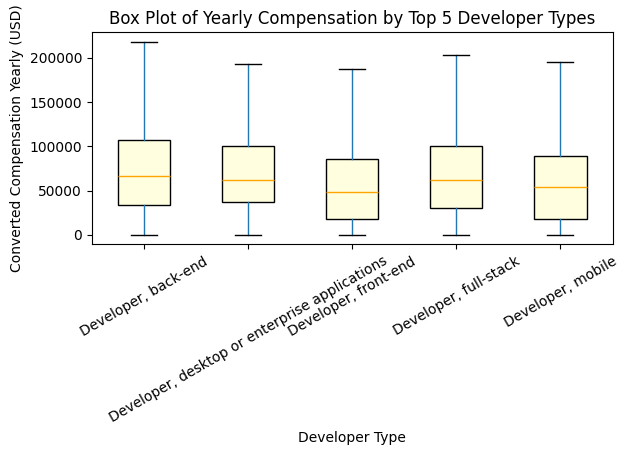

In [12]:
# your code goes here

# Connect to SQLite and load the data
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop missing values
df = df[['DevType', 'ConvertedCompYearly']].dropna()

# Split multiple developer types and explode
df_exploded = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')
df_exploded['DevType'] = df_exploded['DevType'].str.strip()

# Get top 5 most frequent developer types
top_devtypes = df_exploded['DevType'].value_counts().nlargest(5).index

# Filter for top 5 developer types
df_top = df_exploded[df_exploded['DevType'].isin(top_devtypes)]

# Optional: remove extreme outliers
df_top = df_top[df_top['ConvertedCompYearly'] < df_top['ConvertedCompYearly'].quantile(0.99)]

# Plot box plot
plt.figure(figsize=(12, 6))
df_top.boxplot(column='ConvertedCompYearly', by='DevType', grid=False, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor='lightyellow', color='black'),
               medianprops=dict(color='orange'))
plt.title('Box Plot of Yearly Compensation by Top 5 Developer Types')
plt.suptitle('')
plt.xlabel('Developer Type')
plt.ylabel('Converted Compensation Yearly (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


<Figure size 1200x600 with 0 Axes>

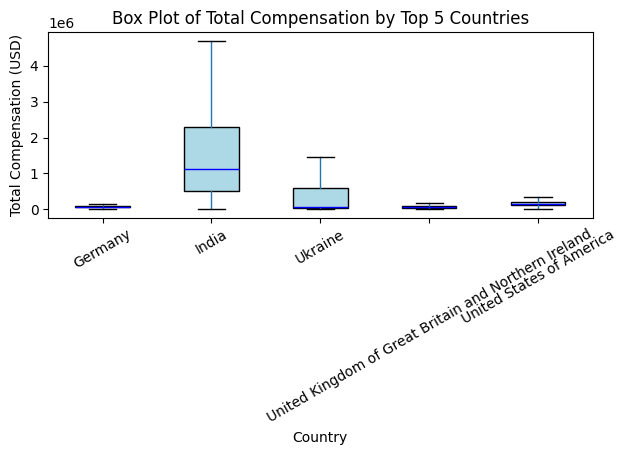

In [13]:
# your code goes here

# Connect to SQLite and load dataset
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop rows with missing Country or CompTotal
df = df[['Country', 'CompTotal']].dropna()

# Get top 5 countries by response count
top_countries = df['Country'].value_counts().nlargest(5).index

# Filter data for top 5 countries only
df_top_countries = df[df['Country'].isin(top_countries)]

# Optional: remove outliers (e.g., top 1% CompTotal)
df_top_countries = df_top_countries[df_top_countries['CompTotal'] < df_top_countries['CompTotal'].quantile(0.99)]

# Plot box plot grouped by Country
plt.figure(figsize=(12, 6))
df_top_countries.boxplot(column='CompTotal', by='Country', grid=False, showfliers=False, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='black'),
                         medianprops=dict(color='blue'))
plt.title('Box Plot of Total Compensation by Top 5 Countries')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('Total Compensation (USD)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/tmp/ipykernel_870/1476666044.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

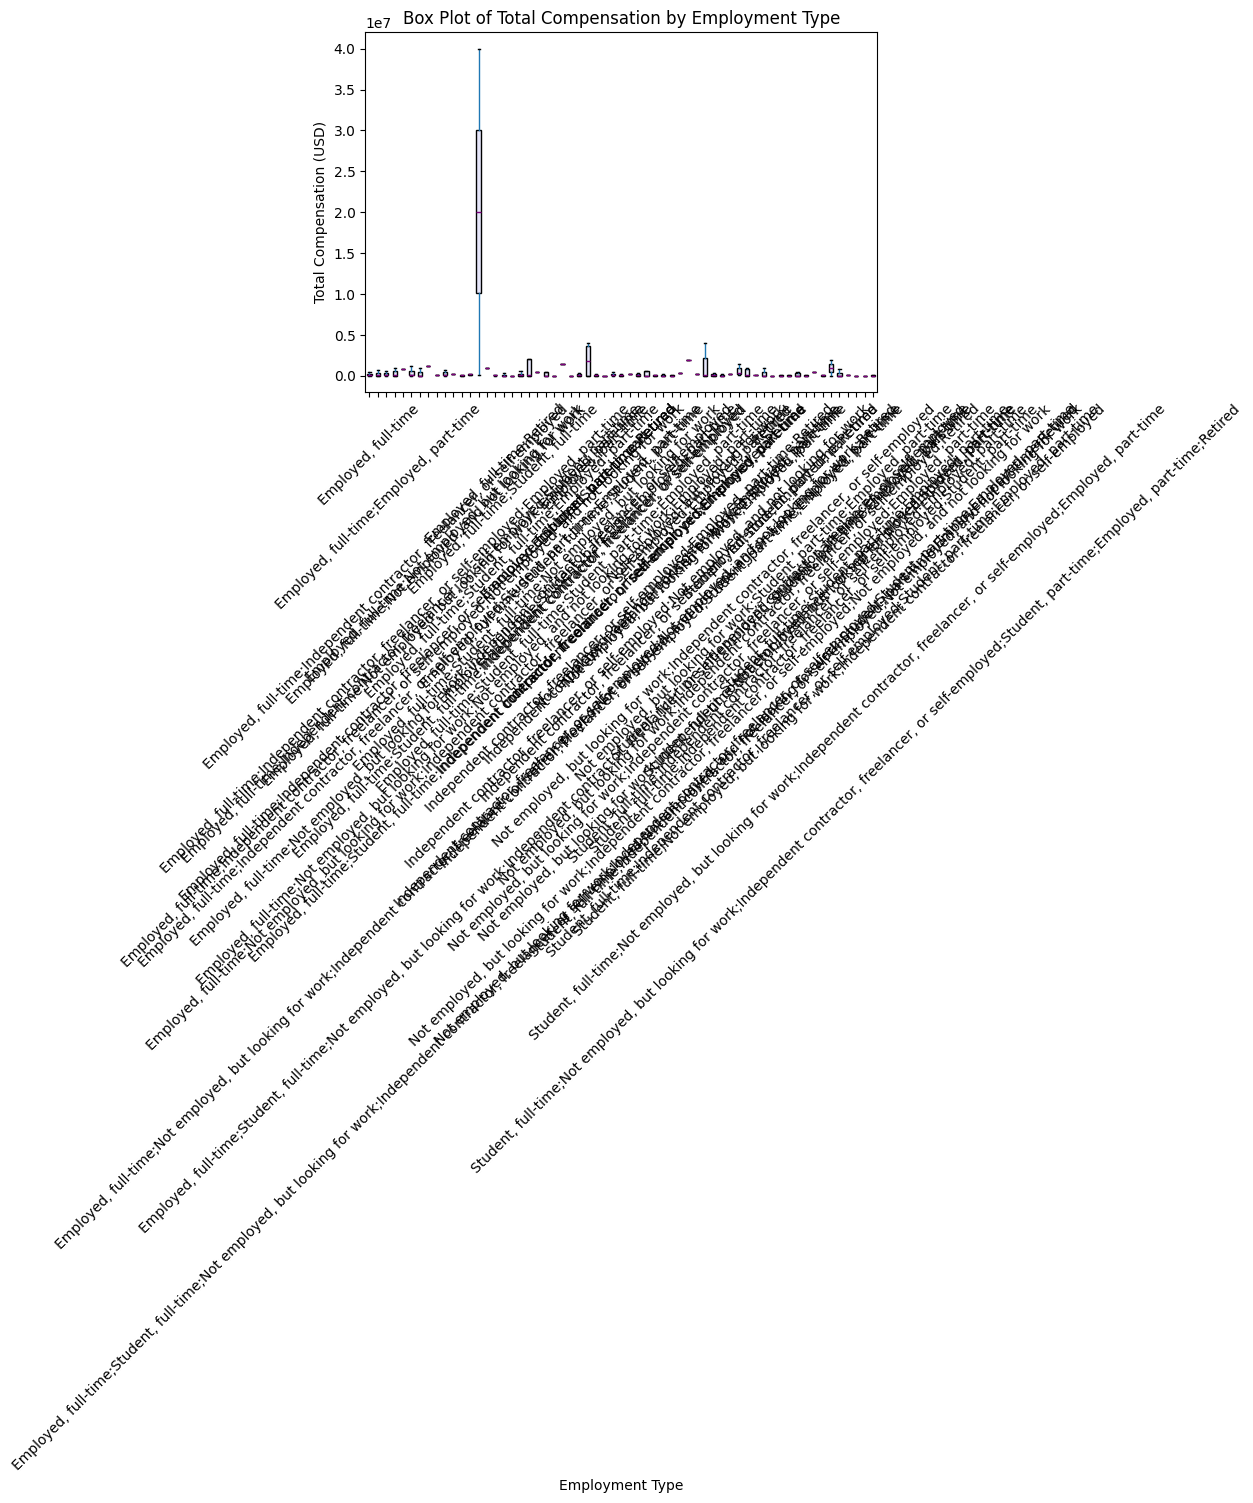

In [14]:
# your code goes here

# Connect to SQLite and load dataset
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Drop rows with missing Employment or CompTotal
df = df[['Employment', 'CompTotal']].dropna()

# Optional: remove outliers in CompTotal (e.g., top 1%) for better visualization
df = df[df['CompTotal'] < df['CompTotal'].quantile(0.99)]

# Plot box plot grouped by Employment type
plt.figure(figsize=(12, 6))
df.boxplot(column='CompTotal', by='Employment', grid=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='lavender', color='black'),
           medianprops=dict(color='purple'))
plt.title('Box Plot of Total Compensation by Employment Type')
plt.suptitle('')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


<Figure size 1200x600 with 0 Axes>

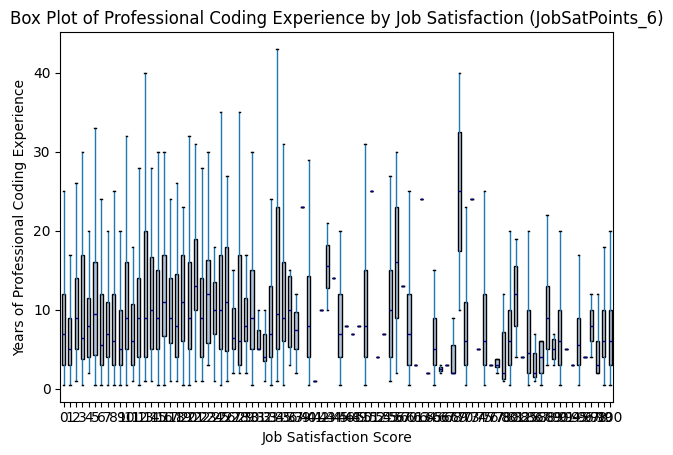

In [15]:
# your code goes here

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to SQLite and load dataset
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT * FROM main", conn)
conn.close()

# Replace string values in YearsCodePro and convert to float
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
}).astype(float)

# Drop rows with missing YearsCodePro or JobSatPoints_6
df = df[['YearsCodePro', 'JobSatPoints_6']].dropna()

# Convert JobSatPoints_6 to integer for sorting/grouping
df['JobSatPoints_6'] = df['JobSatPoints_6'].astype(int)

# Optional: filter unrealistic high values
df = df[df['YearsCodePro'] <= 51]

# Plot box plot grouped by Job Satisfaction
plt.figure(figsize=(12, 6))
df.boxplot(column='YearsCodePro', by='JobSatPoints_6', grid=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', color='black'),
           medianprops=dict(color='darkblue'))
plt.title('Box Plot of Professional Coding Experience by Job Satisfaction (JobSatPoints_6)')
plt.suptitle('')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Years of Professional Coding Experience')
plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [16]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
